<a href="https://colab.research.google.com/github/irma3111111/Submission-Proyek-Pertama-ML-Terapan/blob/main/SAUBMISSION_ML_Terapan_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Irma Rohmatillah - MC222D5X0904

# **Prediksi Default Pinjaman pada Fintech menggunakan Machine Learning**

> Dataset yang digunakan : [Loan Default Dataset](https://www.kaggle.com/datasets/yasserh/loan-default-dataset)

> Proyek ini bertujuan untuk memprediksi kemungkinan terjadinya gagal bayar dengan menggunakan teknik machine learning. Dengan menganalisis data historis pinjaman, model akan membantu perusahaan fintech mengidentifikasi calon peminjam yang berpotensi default.

- Pendekatan ini memungkinkan perusahaan untuk:
- Mengelola risiko kredit secara proaktif
- Mengambil keputusan yang lebih tepat dalam pemberian pinjaman
- Meningkatkan efisiensi dan keamanan sistem keuangan

> Dengan bantuan data yang tersedia, sistem prediksi ini diharapkan dapat menjadi alat bantu yang andal dalam proses penilaian kelayakan pinjaman.

----


**1. Import Library yang Dibutuhkan**

> Tahap ini digunakan untuk memuat semua library yang diperlukan dalam analisis data dan pengembangan model machine learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

**2. Data Understanding**

> Bagian ini bertujuan memahami struktur dan isi dataset, termasuk informasi variabel serta distribusi datanya.


*2.1 Data Loading*

In [2]:
df = pd.read_csv("Loan_Default.csv")
df.drop(columns=['ID'], inplace=True)

*2.2 Exploratory Data Analysis (EDA)*
> Exploratory Data Analysis digunakan untuk memahami pola, outlier, dan karakteristik penting dari data sebelum membangun model.


2.2.1 Deskripsi Variabel

In [3]:
print(df.describe(include='all'))

            year loan_limit  Gender approv_in_adv loan_type loan_purpose  \
count   148670.0     145326  148670        147762    148670       148536   
unique       NaN          2       4             2         3            4   
top          NaN         cf    Male         nopre     type1           p3   
freq         NaN     135348   42346        124621    113173        55934   
mean      2019.0        NaN     NaN           NaN       NaN          NaN   
std          0.0        NaN     NaN           NaN       NaN          NaN   
min       2019.0        NaN     NaN           NaN       NaN          NaN   
25%       2019.0        NaN     NaN           NaN       NaN          NaN   
50%       2019.0        NaN     NaN           NaN       NaN          NaN   
75%       2019.0        NaN     NaN           NaN       NaN          NaN   
max       2019.0        NaN     NaN           NaN       NaN          NaN   

       Credit_Worthiness open_credit business_or_commercial   loan_amount  \
count     

2.2.2 Menangani Missing Value dan Outliers

In [4]:
# Pisahkan kolom numerik dan kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'Status' in num_cols:
    num_cols.remove('Status')
if 'Status' in cat_cols:
    cat_cols.remove('Status')

# Imputasi missing value
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

2.2.3 Univariate Analysis

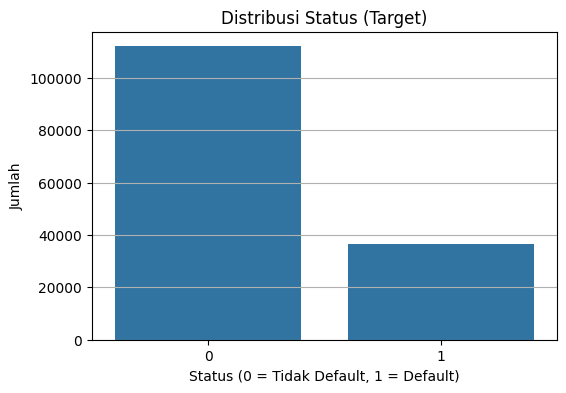

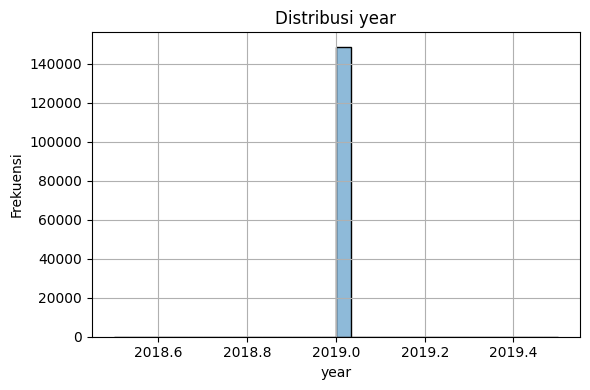

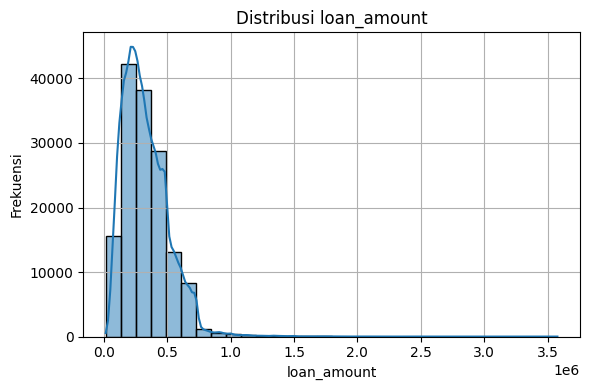

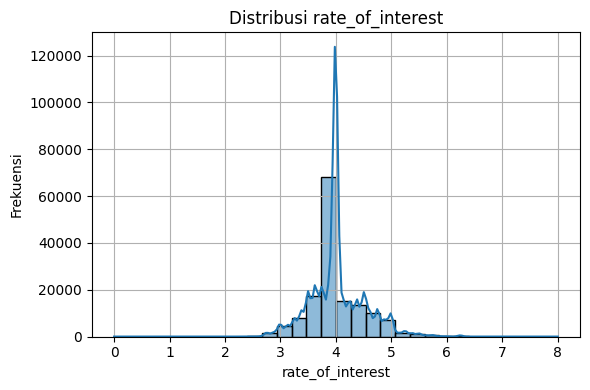

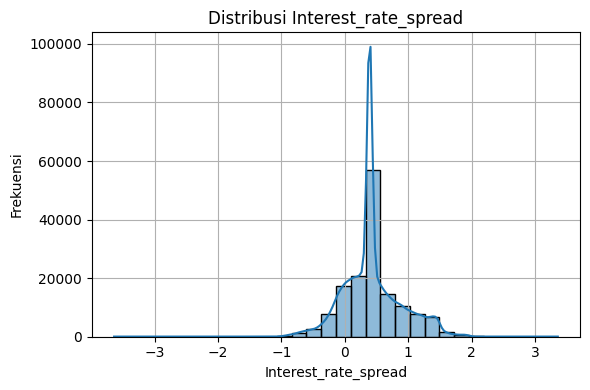

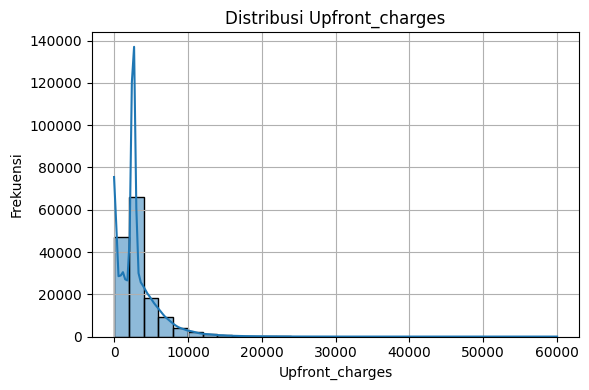

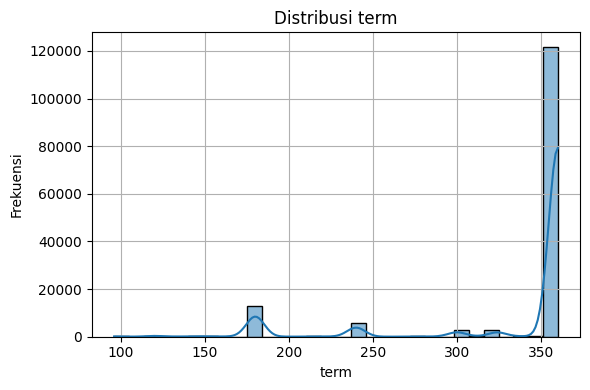

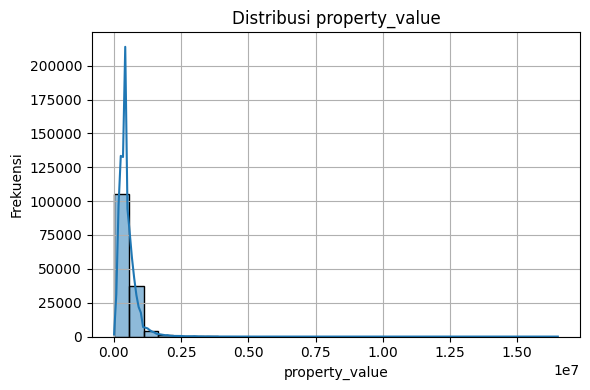

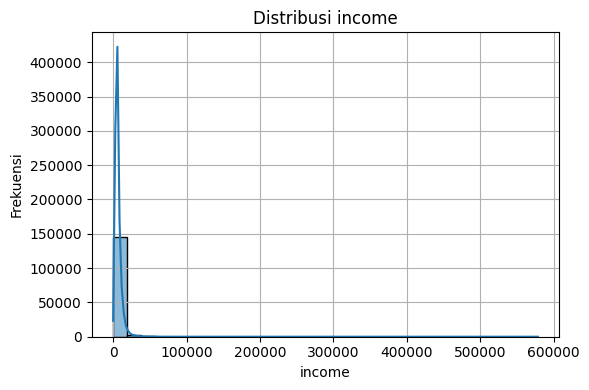

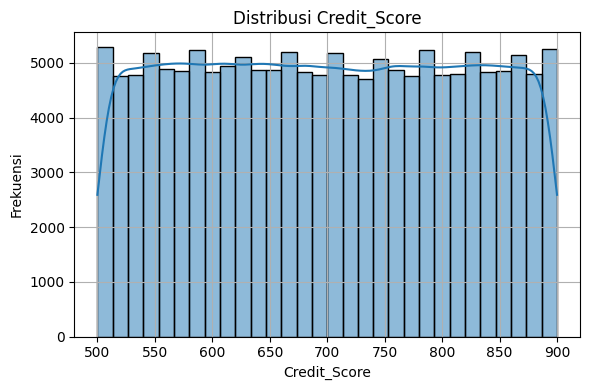

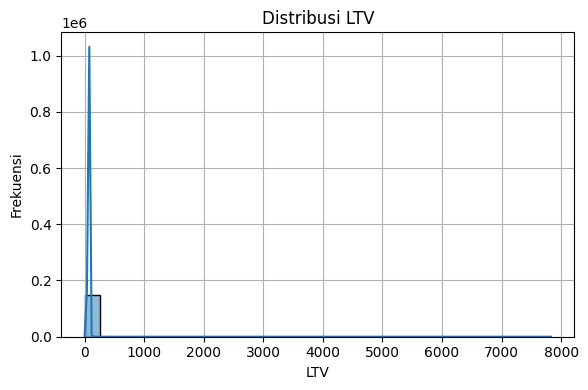

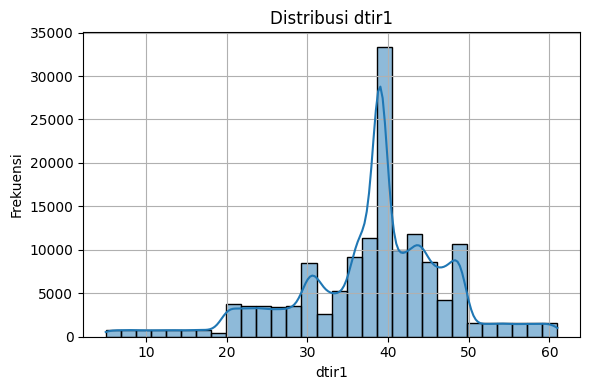

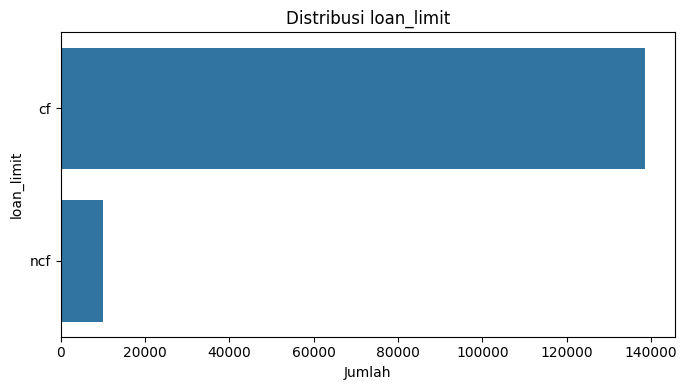

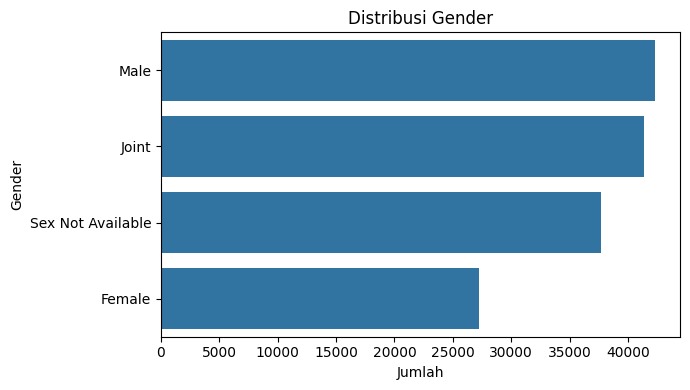

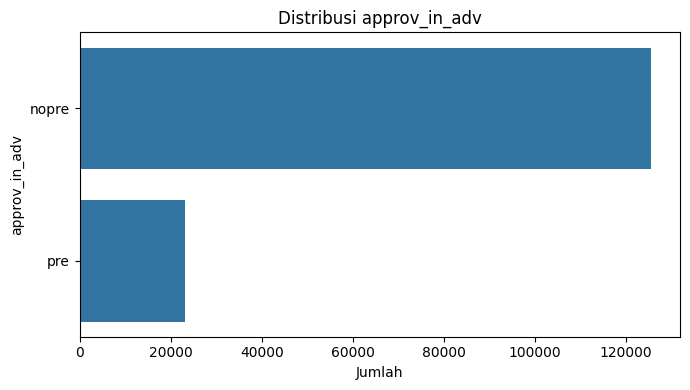

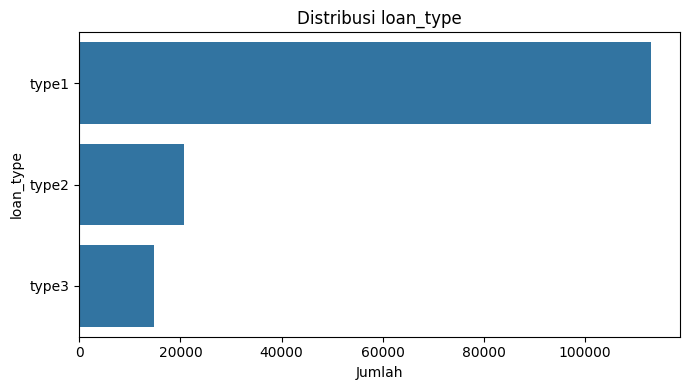

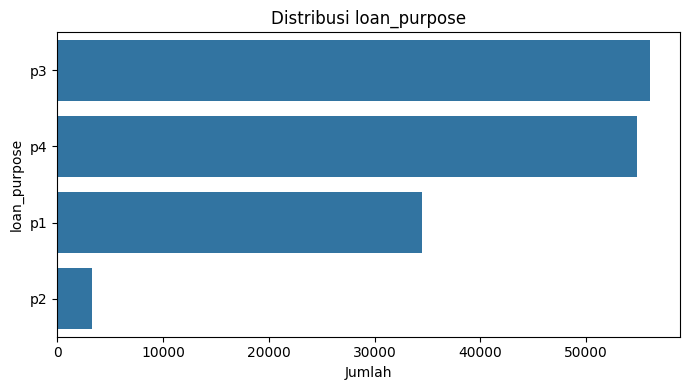

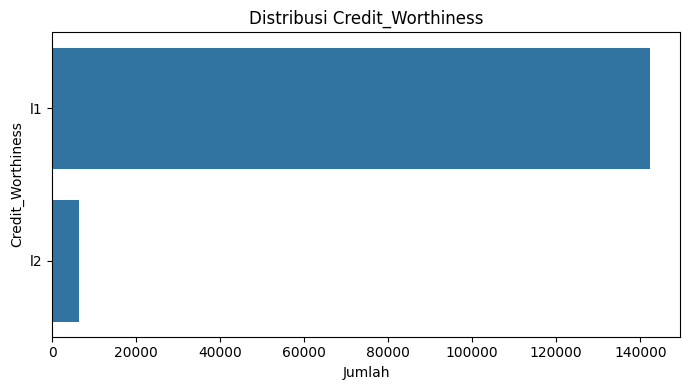

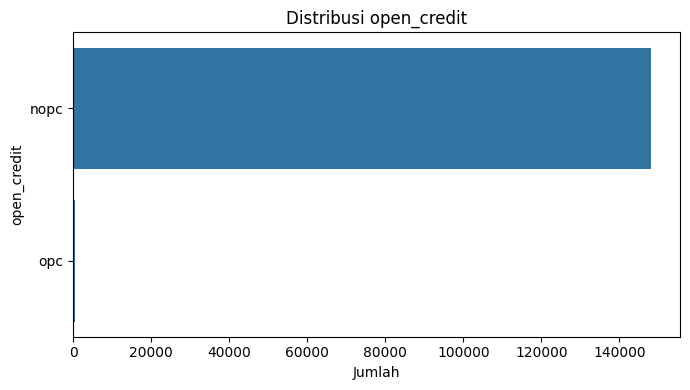

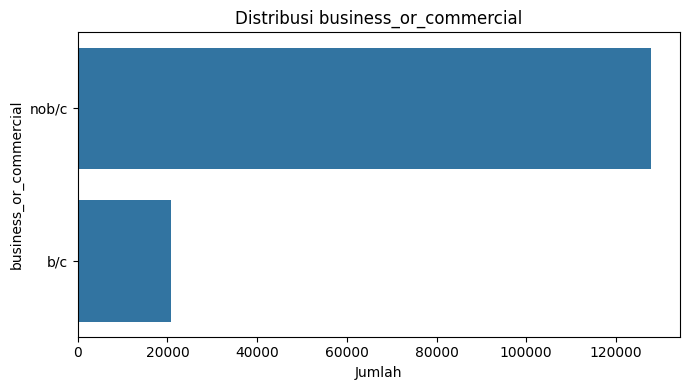

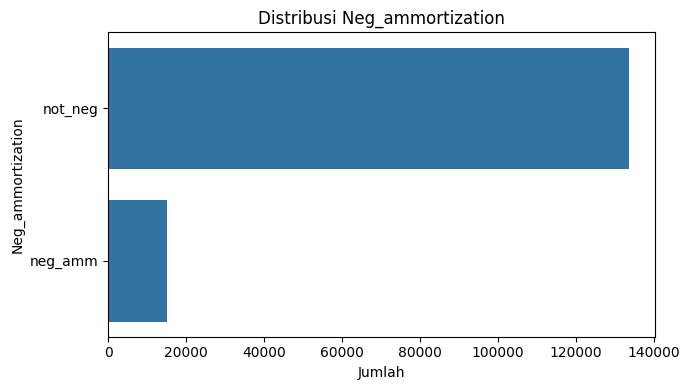

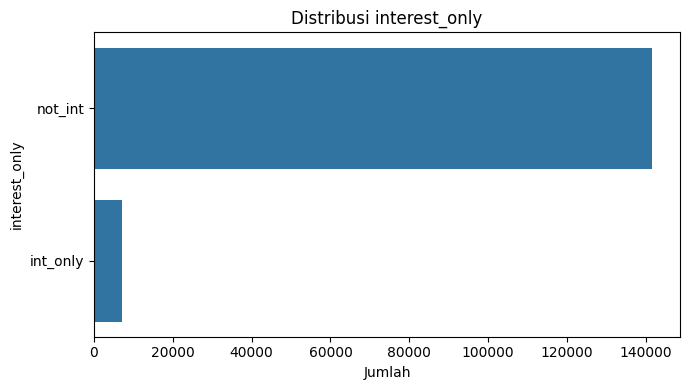

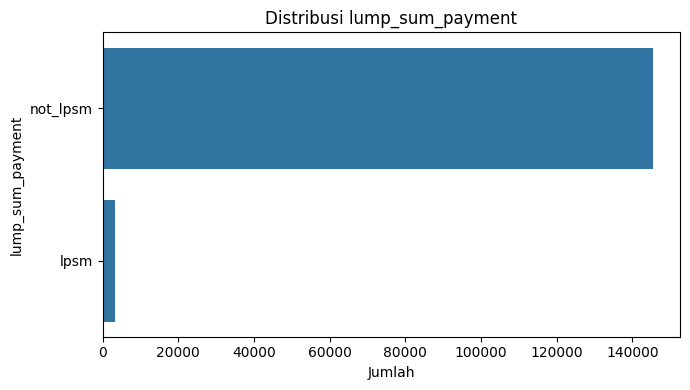

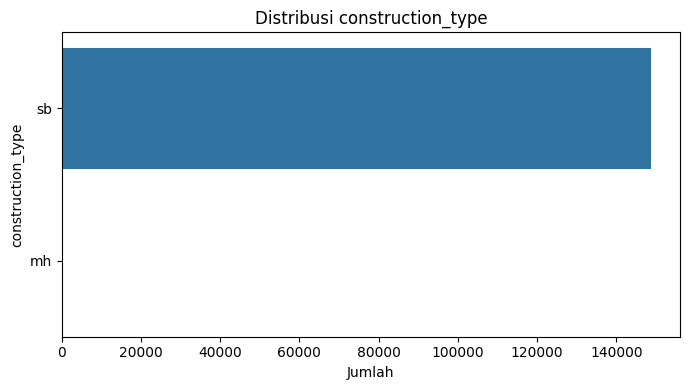

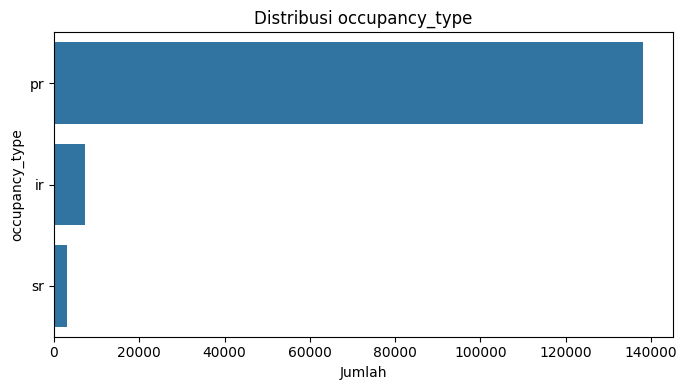

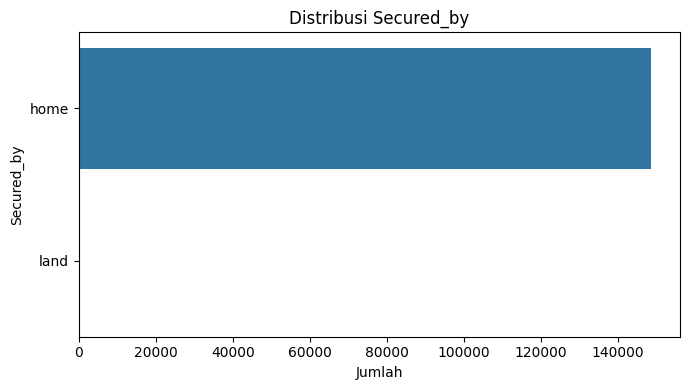

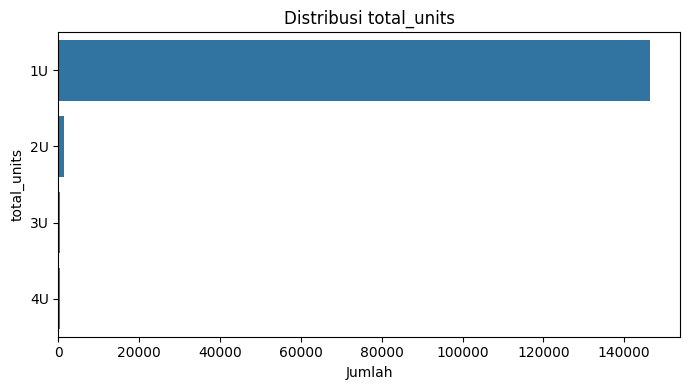

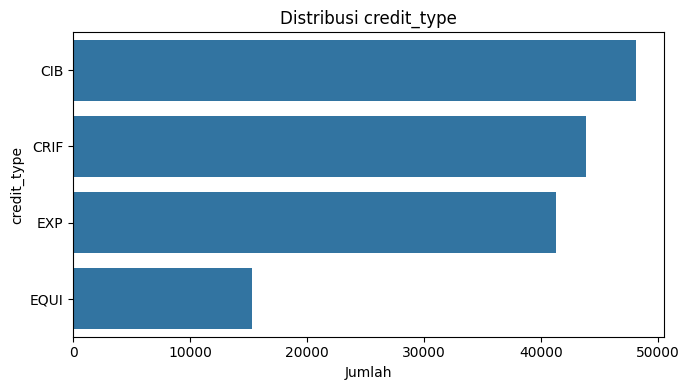

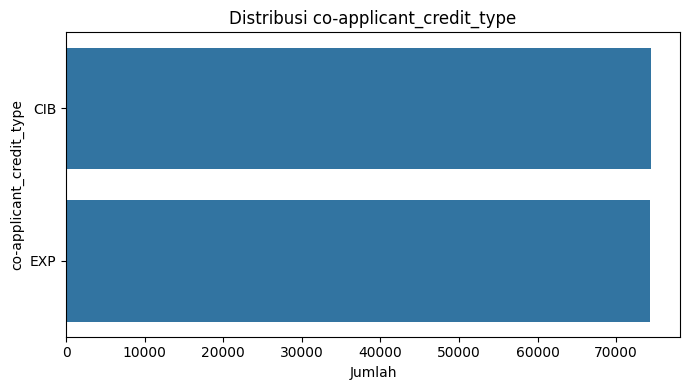

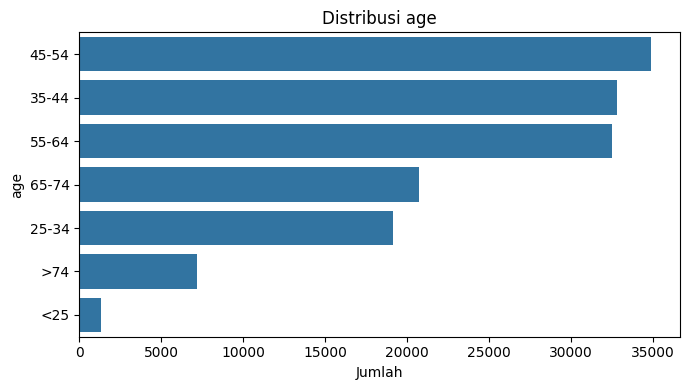

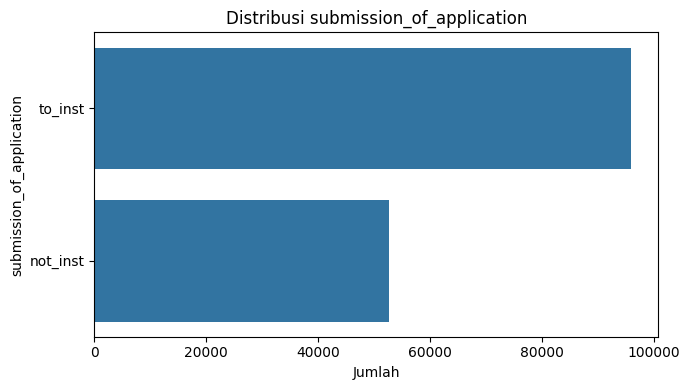

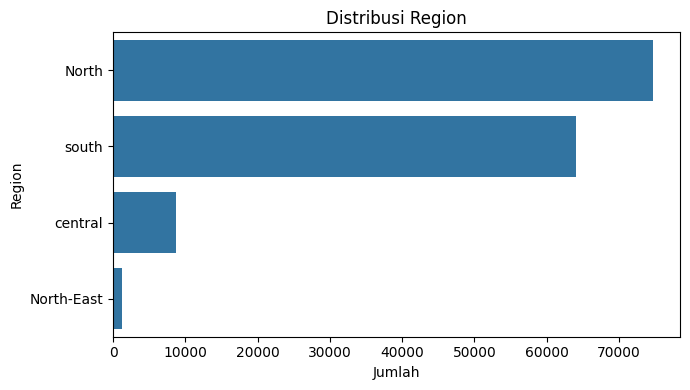

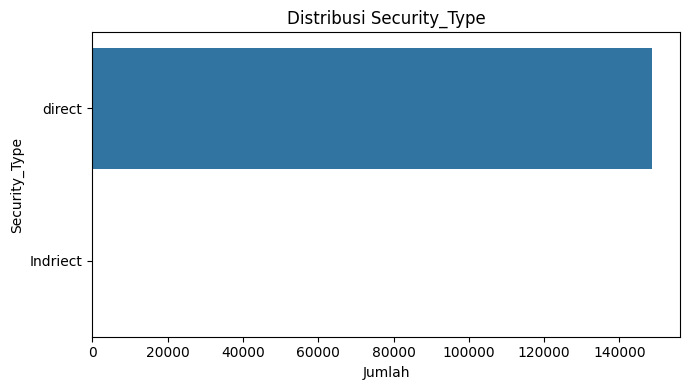

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Status', data=df)
plt.title('Distribusi Status (Target)')
plt.xlabel('Status (0 = Tidak Default, 1 = Default)')
plt.ylabel('Jumlah')
plt.grid(axis='y')
plt.show()

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().iloc[:10].index)
    plt.title(f'Distribusi {col}')
    plt.xlabel('Jumlah')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

2.2.4 Multivariate Analysis

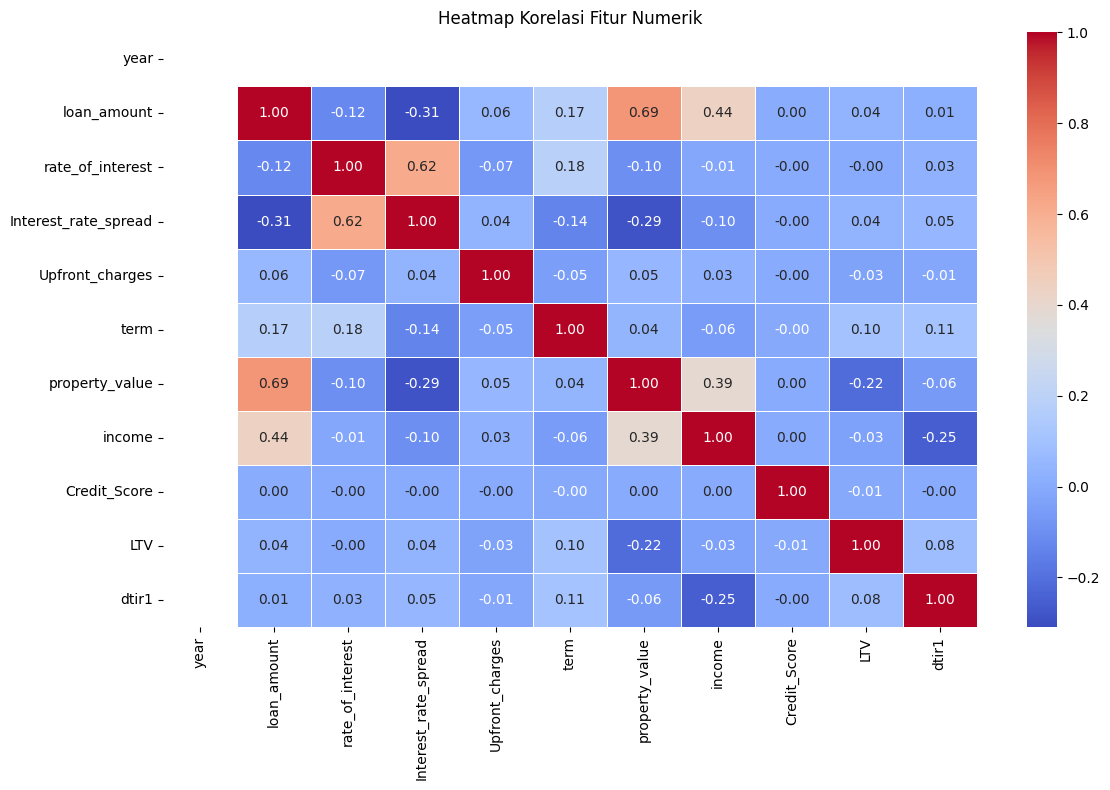

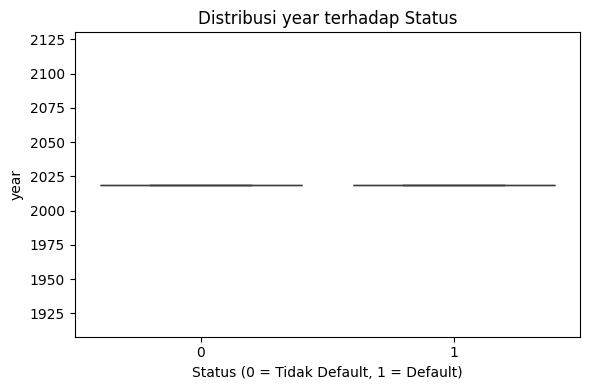

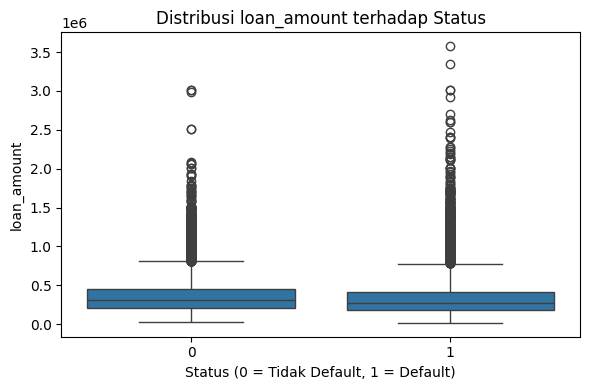

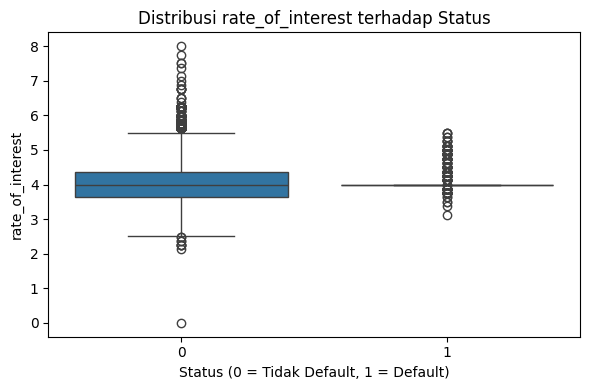

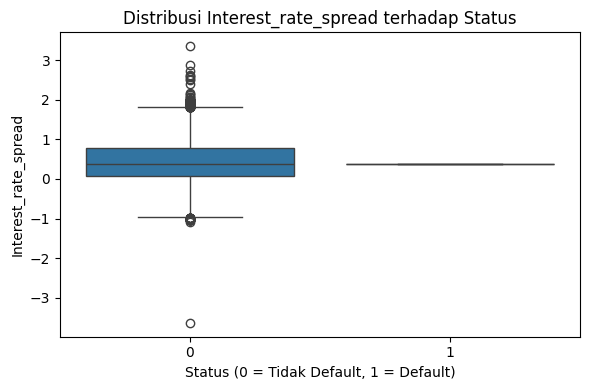

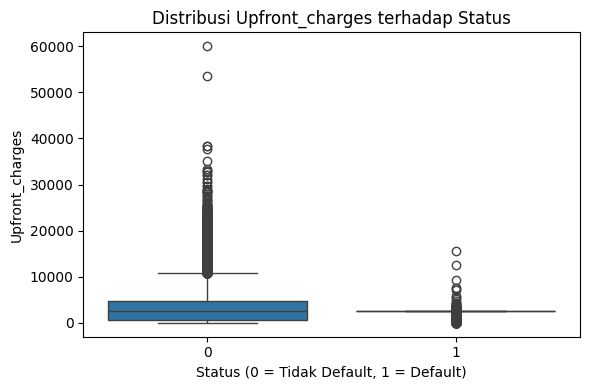

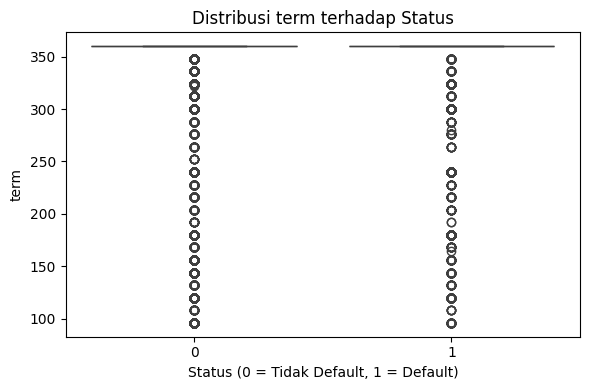

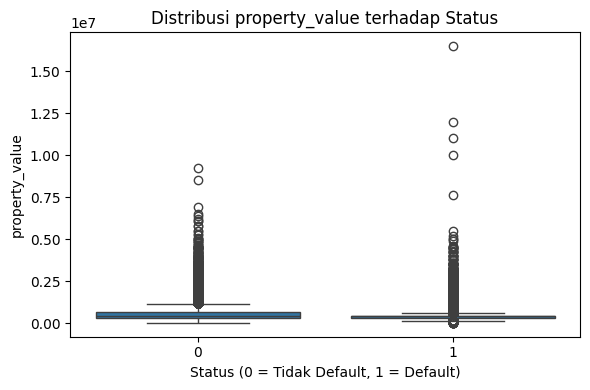

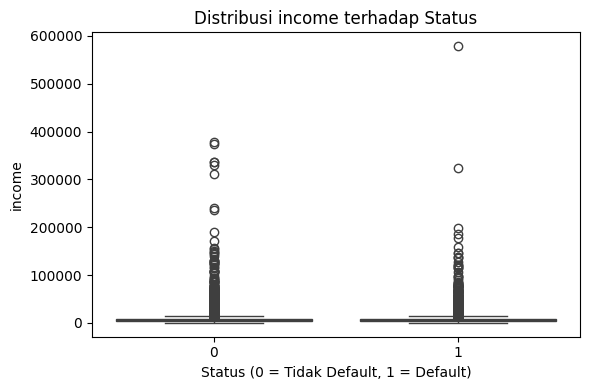

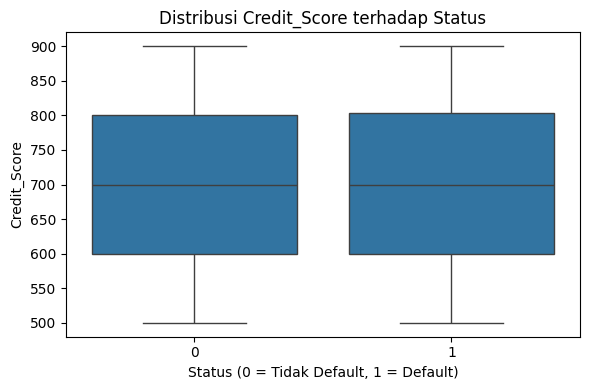

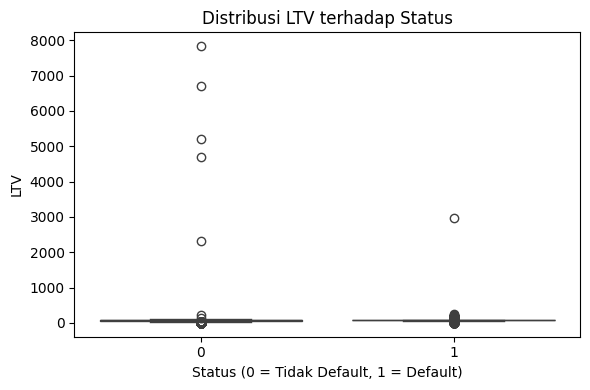

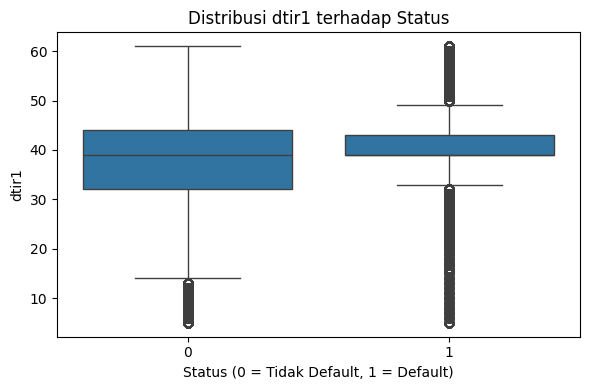

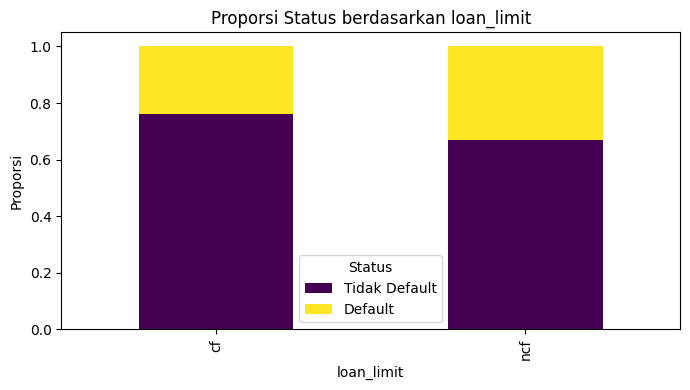

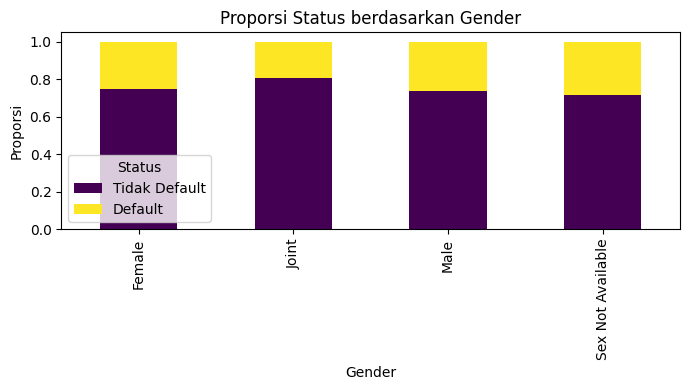

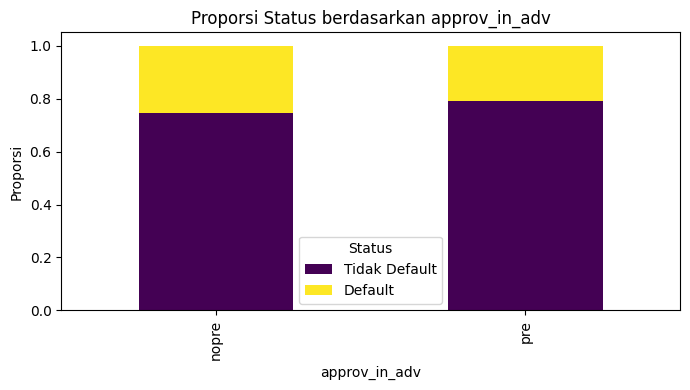

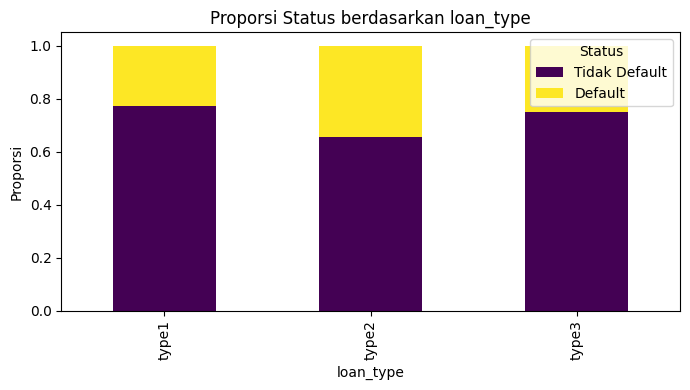

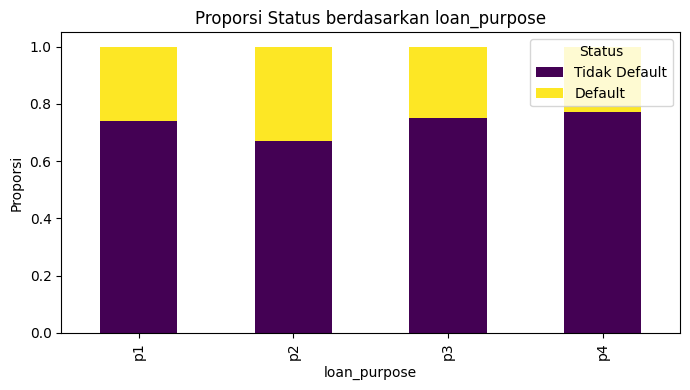

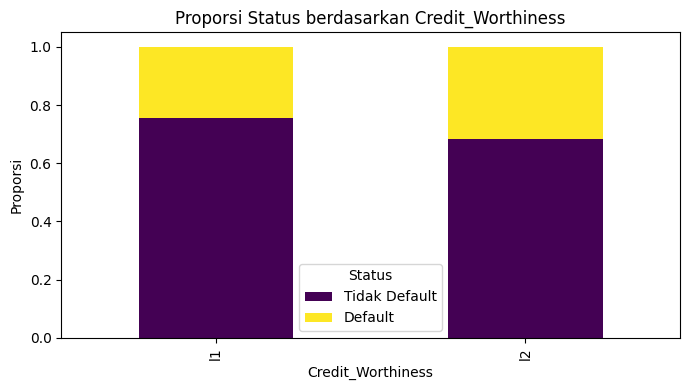

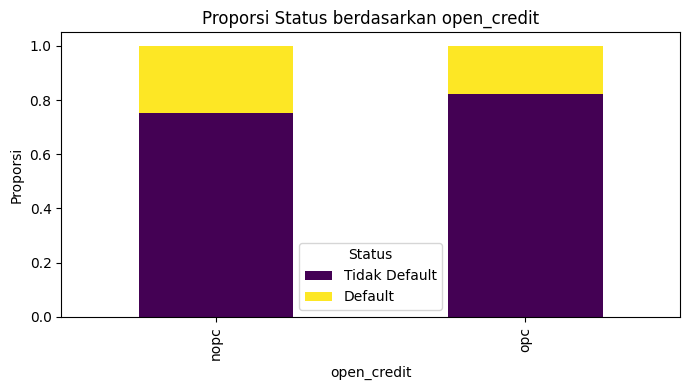

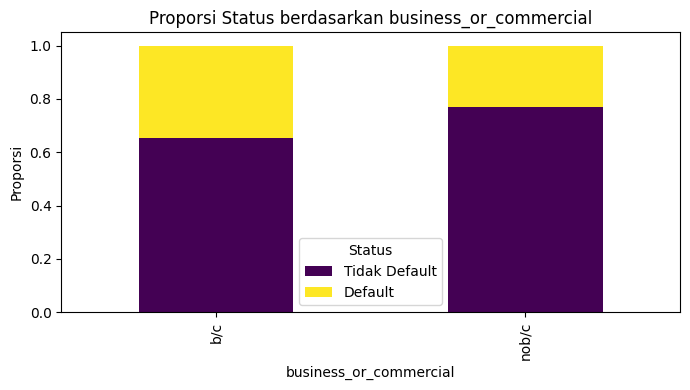

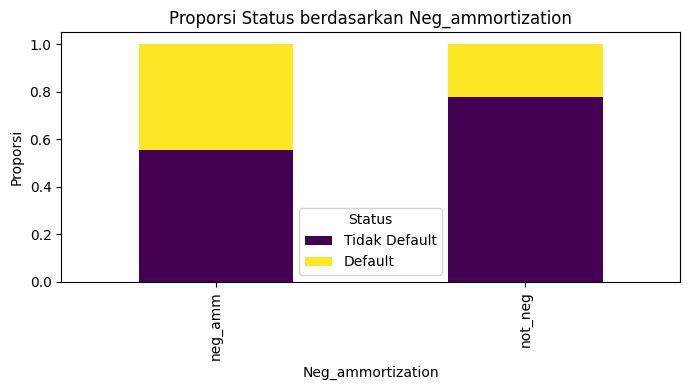

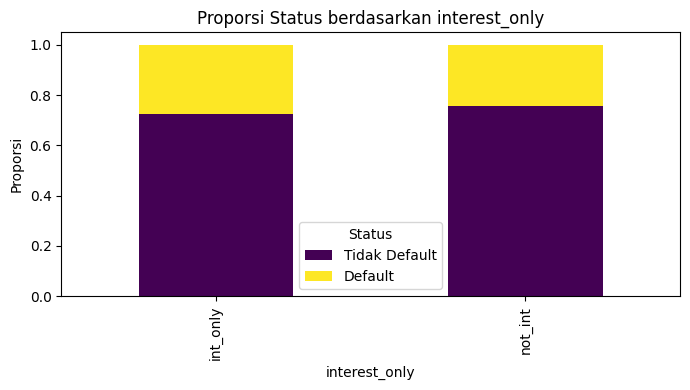

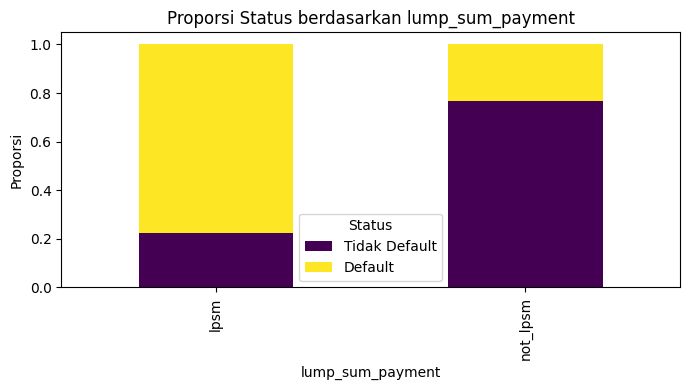

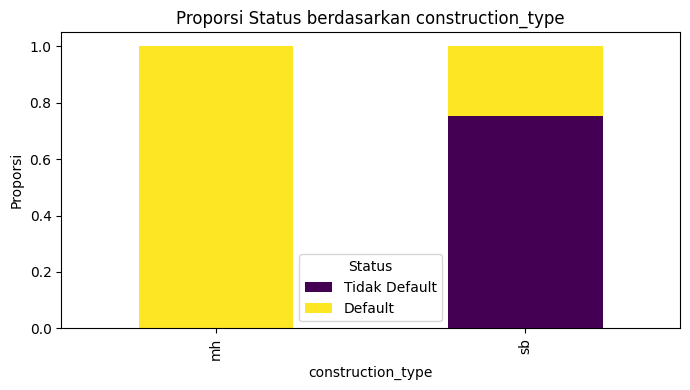

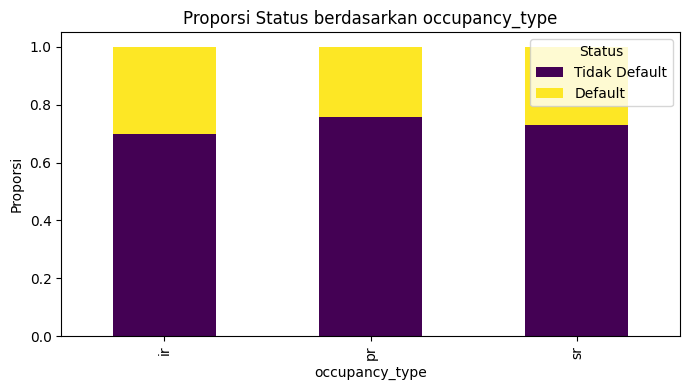

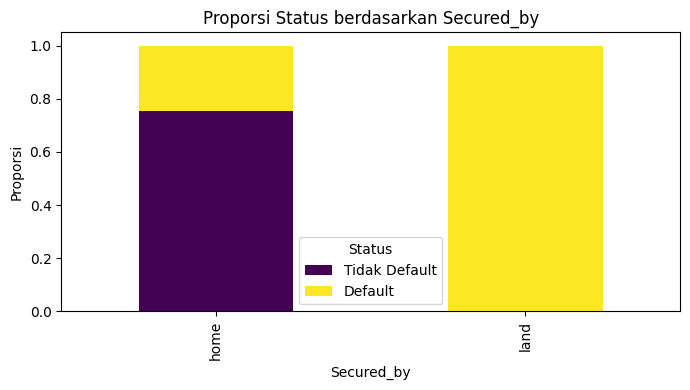

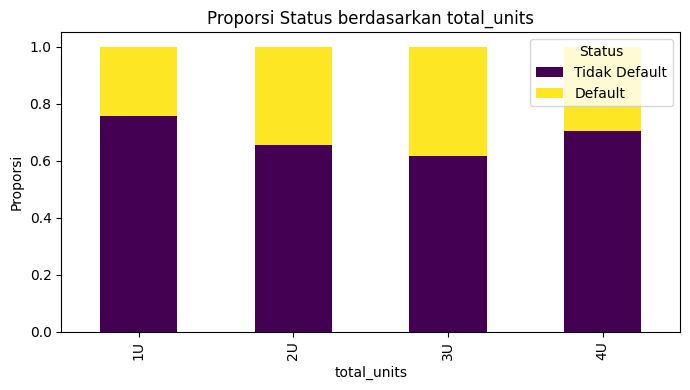

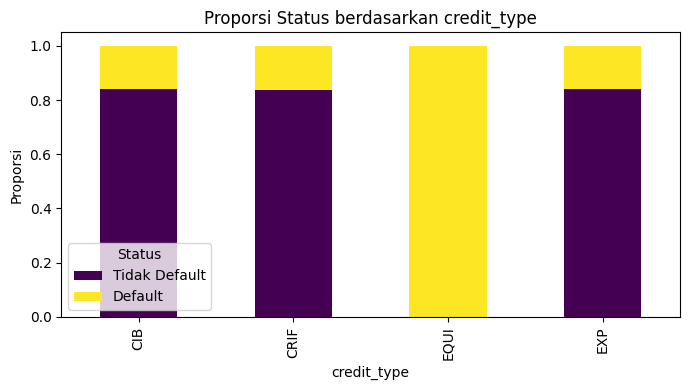

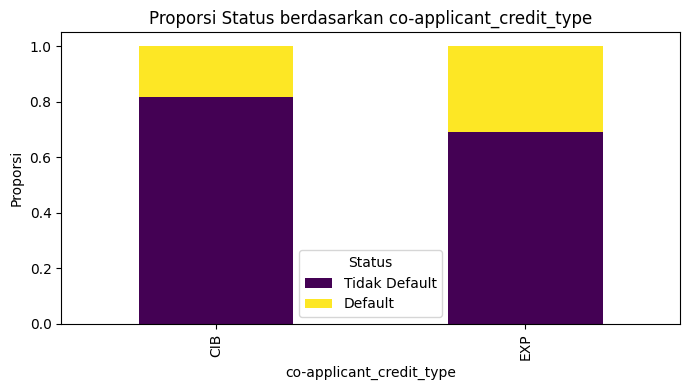

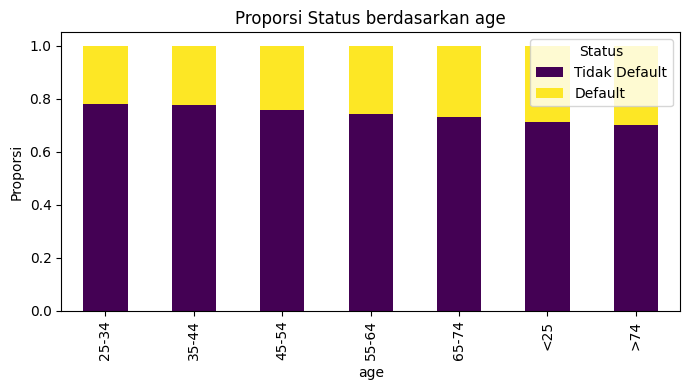

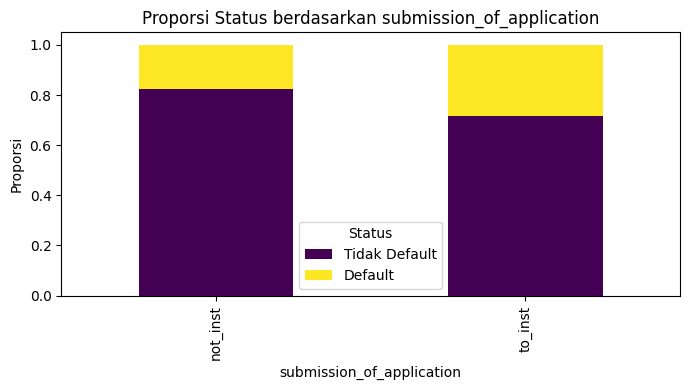

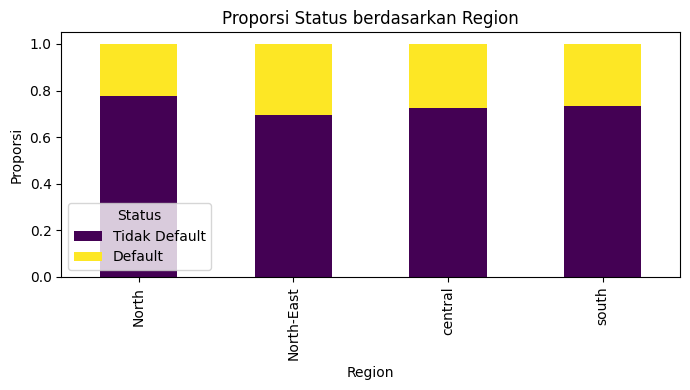

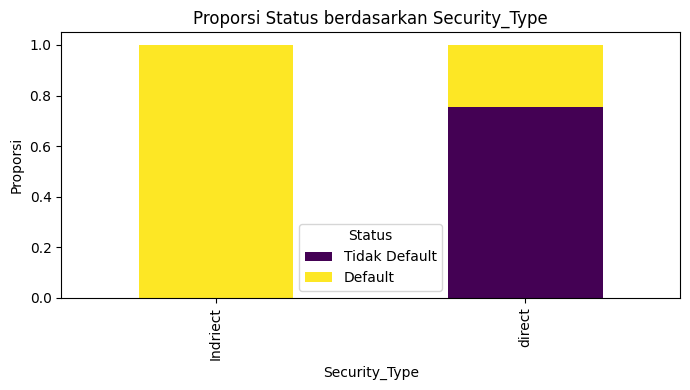

In [6]:
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Status', y=col, data=df)
    plt.title(f'Distribusi {col} terhadap Status')
    plt.xlabel('Status (0 = Tidak Default, 1 = Default)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    cross_tab = pd.crosstab(df[col], df['Status'], normalize='index')
    cross_tab.plot(kind='bar', stacked=True, figsize=(7, 4), colormap='viridis')
    plt.title(f'Proporsi Status berdasarkan {col}')
    plt.xlabel(col)
    plt.ylabel('Proporsi')
    plt.legend(title='Status', labels=['Tidak Default', 'Default'])
    plt.tight_layout()
    plt.show()

**3. Data Preparation**

> Pada tahap ini dilakukan pemisahan data latih dan uji, serta normalisasi agar model dapat bekerja optimal.


3.1 Train-Test-Split

In [7]:
X = df.drop(columns='Status')
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3.2 preprocesing

In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])

In [9]:
# SMOTE untuk class imbalance
smote = SMOTE(random_state=42)

**4. Model Development**

> Tahap pengembangan model digunakan untuk melatih model klasifikasi machine learning berdasarkan data yang telah diproses.


4.1 Membangun model

In [10]:
# Pipeline Model - Random Forest
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'loan_amount',
                                                   'rate_of_interest',
                                                   'Interest_rate_spread',
                                                   'Upfront_charges', 'term',
                                                   'property_value', 'income',
                                                   'Credit_Score', 'LTV',
                                                   'dtir1']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['loan_limit', 'Gender',
                                                   'approv_in_adv', 'l...
                                                   'open_credit',
                                                   'business_or_commercial',
                                                   'Neg_ammortization',
                                                   'interest_only',
                                                   'lump_sum_payment',
                                                   'construction_type',
                                                   'occupancy_type',
                                                   'Secured_by', 'total_units',
                                                   'credit_type',
                                                   'co-applicant_credit_type',
                                                   'age',
                                                   'submission_of_application',
                                                   'Region',
                                                   'Security_Type'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier(random_state=42))])

In [11]:
# Pipeline Model - Logistic Regression
logreg_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'loan_amount',
                                                   'rate_of_interest',
                                                   'Interest_rate_spread',
                                                   'Upfront_charges', 'term',
                                                   'property_value', 'income',
                                                   'Credit_Score', 'LTV',
                                                   'dtir1']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['loan_limit', 'Gender',
                                                   'approv_in_adv', 'l...
                                                   'open_credit',
                                                   'business_or_commercial',
                                                   'Neg_ammortization',
                                                   'interest_only',
                                                   'lump_sum_payment',
                                                   'construction_type',
                                                   'occupancy_type',
                                                   'Secured_by', 'total_units',
                                                   'credit_type',
                                                   'co-applicant_credit_type',
                                                   'age',
                                                   'submission_of_application',
                                                   'Region',
                                                   'Security_Type'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

**5. Evaluasi Model**

> Evaluasi dilakukan untuk menilai seberapa baik performa model terhadap data uji menggunakan metrik akurasi dan classification report.


In [12]:
# Evaluasi Random Forest
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("[Random Forest]")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

[Random Forest]
MSE: 3.363153292527074e-05
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     22494
           1       1.00      1.00      1.00      7240

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



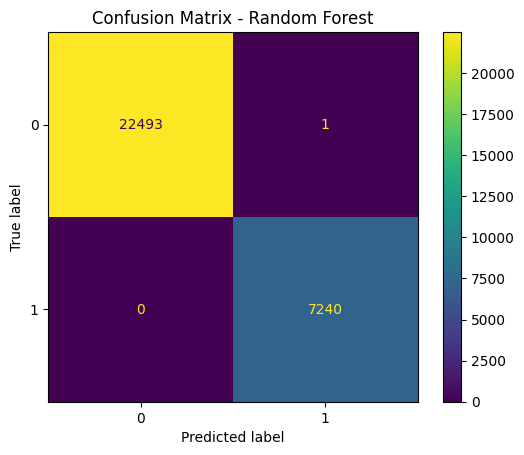

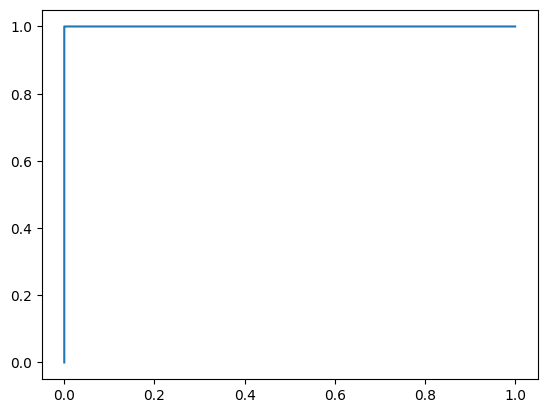

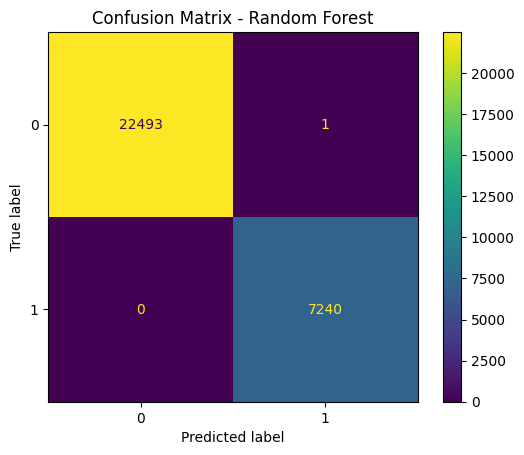

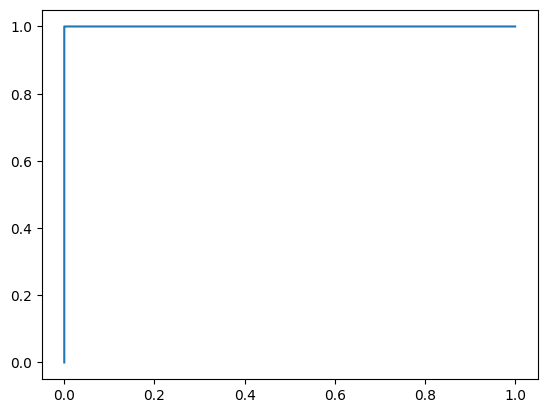

In [13]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

auc_score_rf = roc_auc_score(y_test, y_proba_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_score_rf:.2f}")
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

auc_score_rf = roc_auc_score(y_test, y_proba_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_score_rf:.2f}")

In [14]:
# Evaluasi Logistic Regression
y_pred_lr = logreg_pipeline.predict(X_test)
y_proba_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

print("\n[Logistic Regression]")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


[Logistic Regression]
MSE: 0.3021456918006323
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.70      0.78     22494
           1       0.42      0.68      0.52      7240

    accuracy                           0.70     29734
   macro avg       0.65      0.69      0.65     29734
weighted avg       0.76      0.70      0.72     29734



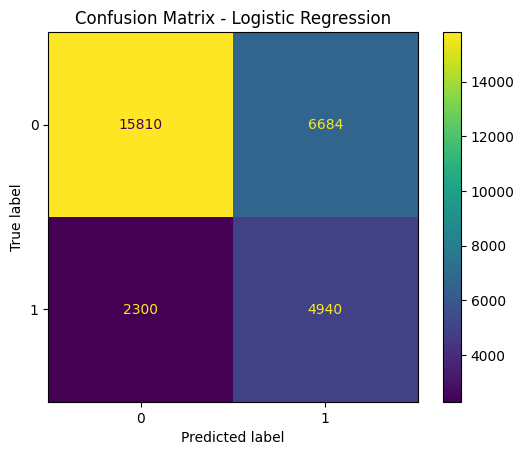

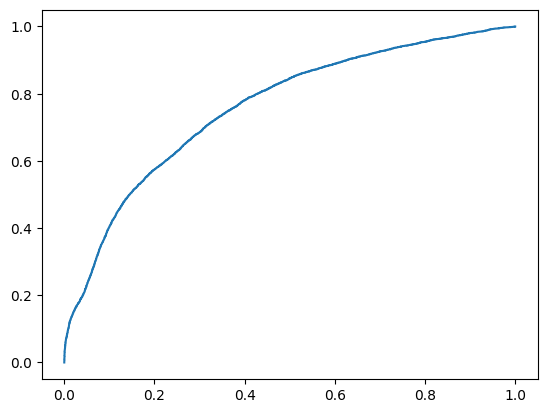

In [15]:
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_lr)
disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

auc_score_lr = roc_auc_score(y_test, y_proba_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression AUC = {auc_score_lr:.2f}")

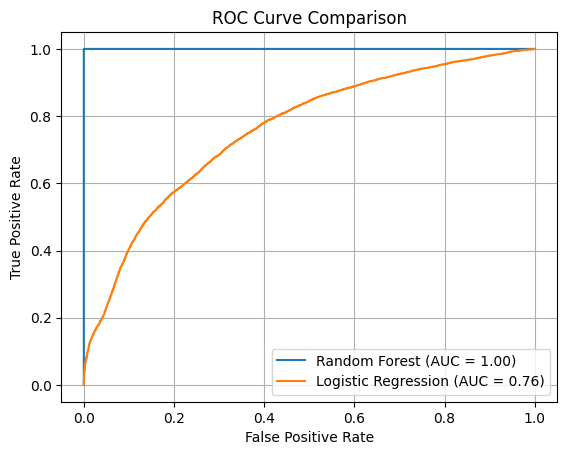

In [16]:
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_score_rf:.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_score_lr:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Cross Validation
cv_scores_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy')
cv_scores_lr = cross_val_score(logreg_pipeline, X, y, cv=5, scoring='accuracy')
print("CV Accuracy [Random Forest]:", cv_scores_rf.mean())
print("CV Accuracy [Logistic Regression]:", cv_scores_lr.mean())

CV Accuracy [Random Forest]: 0.9999865473868299
CV Accuracy [Logistic Regression]: 0.6994417165534406


In [ ]:
# Hyperparameter Tuning untuk Random Forest
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}
grid_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', RandomForestClassifier(random_state=42))
])
grid_search = GridSearchCV(grid_pipeline, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best parameters (Random Forest):", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

In [ ]:
# Feature Importance
final_rf = grid_search.best_estimator_.named_steps['classifier']
feature_names = num_cols + cat_cols
importances = final_rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:\n", importance_df.head(10))